In [10]:
import numpy as np
from aeon.classification.interval_based import RSTSF
from sklearn.metrics import accuracy_score
from autotsc.models import FastStackerV4, StackerV4, FastStackerV5, LokyStackerV5
from autotsc import utils
import boto3
import click
import polars as pl
from aeon.classification.convolution_based import MultiRocketHydraClassifier
from aeon.classification.feature_based import Catch22Classifier
from aeon.classification.hybrid import HIVECOTEV2
from aeon.classification.interval_based import RSTSF, QUANTClassifier, DrCIFClassifier
from aeon.classification.shapelet_based import RDSTClassifier
from aeon.pipeline import make_pipeline as aeon_make_pipeline
from aeon.transformations.collection import Normalizer
from aeon.datasets.tsc_datasets import univariate
from aeon.benchmarking.resampling import stratified_resample_data
from botocore.exceptions import ClientError
from sklearn.metrics import accuracy_score
from catboost import CatBoostClassifier
from time import perf_counter
from pathlib import Path

from autotsc import transformers, utils
from autotsc.models import StackerV4, FastStackerV4, FastStackerV5, LokyStackerV5

In [2]:
dataset = "Worms"
# dataset = 'PigArtPressure'
X_train, y_train, X_test, y_test = utils.load_dataset(dataset)
print(X_train.shape, y_train.shape, X_test.shape, y_test.shape)

(181, 1, 900) (181,) (77, 1, 900) (77,)


In [3]:
n_jobs=16
m1 = MultiRocketHydraClassifier(n_jobs=n_jobs)
m2 = QUANTClassifier()
m3 = RDSTClassifier(n_jobs=n_jobs)
m4 = Catch22Classifier(n_jobs=n_jobs)
m5 = LokyStackerV5(n_jobs=n_jobs)

In [4]:
d = []

for m in [m1, m2, m3, m4, m5]:
    start_train_time = perf_counter()
    m.fit(X_train, y_train)
    end_train_time = perf_counter()
    train_duration = end_train_time - start_train_time
    y_pred = m.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    print(f"{m.__class__.__name__}: {acc:.4f}")
    d.append(
        {
            "model": m.__class__.__name__,
            "accuracy": acc,
            "train_time": train_duration,
        }
    )
df = pl.DataFrame(d)

MultiRocketHydraClassifier: 0.7662
QUANTClassifier: 0.7662
RDSTClassifier: 0.6883
Catch22Classifier: 0.7403
[0.0000s] Starting fitting
[18.1524s] Computed QUANT features in 18.1523s
Starting executor with 16 workers, tmpdir=/tmp/loky_stacker_8mh7ds50
[18.1533s] Starting repetition 0
[19.3617s] Computed MultiRocket features in 1.2084s
[24.2731s] Computed Hydra features in 4.9113s
[28.9360s] Computed RDST features in 4.6626s
[29.3222s] Data saved to mmap files
[29.3225s] Starting training with 16 workers for 40 models
[Worker 2980435] Train init starting...
[Worker 2980435] Loading X...
[Worker 2980435] Loading Xt...
[Worker 2980435] Loading Xt_columns...
[Worker 2980435] Creating DataFrame (94883 cols)...
[Worker 2980437] Train init starting...
[Worker 2980437] Loading X...
[Worker 2980437] Loading Xt...
[Worker 2980437] Loading Xt_columns...
[Worker 2980437] Creating DataFrame (94883 cols)...
[Worker 2980442] Train init starting...
[Worker 2980442] Loading X...
[Worker 2980442] Loading

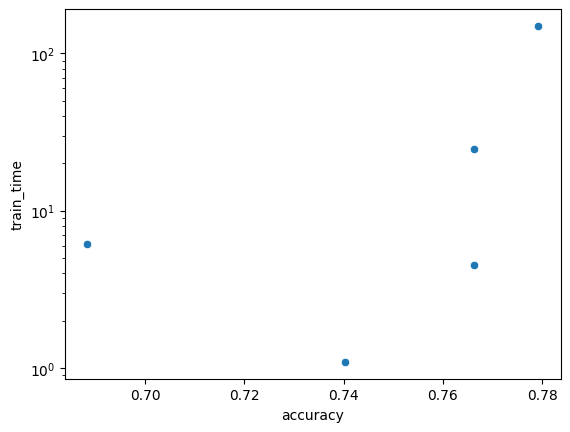

In [11]:
import seaborn as sns
sns.scatterplot(df, x='accuracy', y='train_time')
# make time log scale
import matplotlib.pyplot as plt
plt.yscale('log')

directory = "figures"
Path(directory).mkdir(parents=True, exist_ok=True)
plt.savefig(f"{directory}/train_time.pdf", bbox_inches='tight', pad_inches=0)